In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer

In [9]:
df = pd.read_csv('train.csv',usecols=['GarageQual','FireplaceQu','SalePrice'])

In [10]:
df.head()

,FireplaceQu,GarageQual,SalePrice
0,NaN,TA,208500
1,TA,TA,181500
2,TA,TA,223500
3,Gd,TA,140000
4,TA,TA,250000


In [11]:
# now we can check the percentage of missing values 
df.isnull().mean()

FireplaceQu    0.472603
GarageQual     0.055479
SalePrice      0.000000
dtype: float64

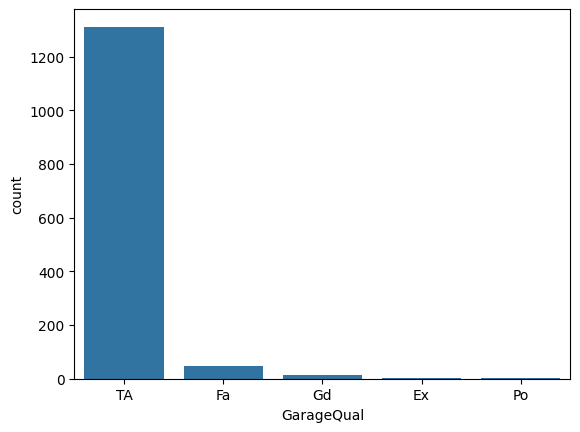

In [13]:
# making plot of garage quality to see the distribution of categories 
sns.countplot(x=df['GarageQual'])
plt.show()

In [14]:
# we can see one frequesnt data is very high over the other data so we can use most frequent here 
df['GarageQual']=df['GarageQual'].fillna('TA')

In [15]:
df.isnull().mean()

FireplaceQu    0.472603
GarageQual     0.000000
SalePrice      0.000000
dtype: float64

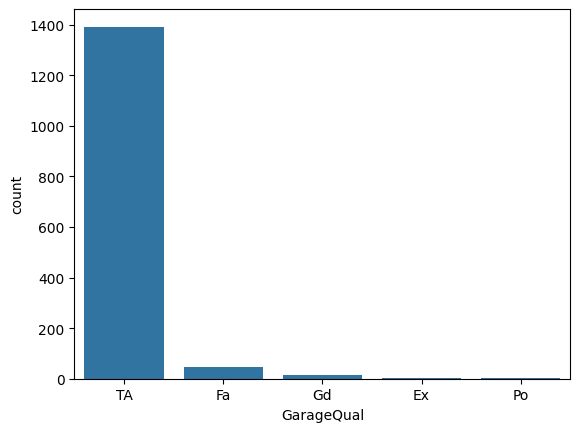

In [16]:
sns.countplot(x=df['GarageQual'])
plt.show()

In [17]:
# using sklearn we can also do this same thing 
x_train,x_test,y_train,y_test = train_test_split(df.iloc[:,0:2],df['SalePrice'],test_size=0.25,random_state=325)

In [18]:
si  = SimpleImputer(strategy='most_frequent')

In [19]:
x_train = si.fit_transform(x_train)
x_test = si.transform(x_test)

In [21]:
x_train

array([['Gd', 'TA'],
       ['Gd', 'TA'],
       ['Po', 'TA'],
       ...,
       ['TA', 'TA'],
       ['TA', 'Ex'],
       ['Gd', 'TA']], shape=(1095, 2), dtype=object)

In [22]:
# for constant values 
x_train,x_test,y_train,y_test = train_test_split(df.iloc[:,0:2],df['SalePrice'],test_size=0.25,random_state=325)

In [23]:
si  = SimpleImputer(strategy='constant',fill_value='Missing')
x_train = si.fit_transform(x_train)
x_test = si.transform(x_test)

In [24]:
x_train

array([['Missing', 'TA'],
       ['Missing', 'TA'],
       ['Po', 'TA'],
       ...,
       ['TA', 'TA'],
       ['TA', 'Ex'],
       ['Missing', 'TA']], shape=(1095, 2), dtype=object)

In [25]:
# We can use this to handle missing categorical data 